# Spice vs FTP Simulation Comparison

Compare SnowStorm Spice Baseline and FTP Baseline simulations for HESE, weighted with the astrophysical flux.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [32]:
import os

save_path = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/'
    'step1_hese_flux/spice_vs_ftp_comparison'
)
os.makedirs(save_path, exist_ok=True)

## Load datasets

In [33]:
PATH_SPICE = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/combined/'
    'IC86_pass2_SnowStorm_v2_Spice_Baseline/'
    'dataset_IC86_pass2_SnowStorm_v2_Spice_Baseline.parquet'
)
PATH_FTP = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/combined/'
    'IC86_pass2_SnowStorm_v2_FTP_Baseline_hdf-v7_noMuon_fluxlessweight/'
    'dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_hdf-v7_noMuon_fluxlessweight.parquet'
)

df_spice = pd.read_parquet(PATH_SPICE)
df_ftp   = pd.read_parquet(PATH_FTP)

print(f'Spice: {len(df_spice):,} events | FTP: {len(df_ftp):,} events')
print(f'Spice columns: {len(df_spice.columns)} | FTP columns: {len(df_ftp.columns)}')

Spice: 171,125 events | FTP: 370,447 events
Spice columns: 50 | FTP columns: 108


## Flux model and event weighting

In [34]:
# Astrophysical flux parameters
PER_FLAVOR_NORM = 2.12
GAMMA_ASTRO     = 2.87

def AstroFluxModel(energy):
    """Per-flavour astrophysical flux [GeV^-1 cm^-2 s^-1 sr^-1]."""
    return 0.5 * (PER_FLAVOR_NORM * 1e-18) * (energy / 1e5) ** -GAMMA_ASTRO

def powerlaw_to_fluxless_weight(powerlaw, true_energy):
    """Convert powerlaw weight to fluxless weight (used when fluxless_weight is absent)."""
    return powerlaw * 1e18 * (true_energy / 1e5) ** 2

def get_astro_weight(df):
    """Return per-event astrophysical weight."""
    energy = df['MCPrimaryEnergy'].values
    if 'fluxless_weight' in df.columns:
        fw = df['fluxless_weight'].values
    else:
        fw = powerlaw_to_fluxless_weight(df['powerlaw'].values, energy)
    return fw * AstroFluxModel(energy)

In [35]:
# Pre-compute weights and attach to dataframes
df_spice = df_spice.copy()
df_ftp   = df_ftp.copy()

df_spice['astro_weight'] = get_astro_weight(df_spice)
df_ftp['astro_weight']   = get_astro_weight(df_ftp)

# Flavour masks (by absolute MCPrimaryType)
FLAVORS = {
    r'$\nu_e$ (12)':   12,
    r'$\nu_\mu$ (14)': 14,
    r'$\nu_\tau$ (16)': 16,
}

def flavor_mask(df, pdg_abs):
    return df['MCPrimaryType'].abs() == pdg_abs

print('Spice astro-weighted event counts by flavour:')
for label, pdg in FLAVORS.items():
    w = df_spice.loc[flavor_mask(df_spice, pdg), 'astro_weight'].sum()
    print(f'  {label}: {w:.4f}')

print('\nFTP astro-weighted event counts by flavour:')
for label, pdg in FLAVORS.items():
    w = df_ftp.loc[flavor_mask(df_ftp, pdg), 'astro_weight'].sum()
    print(f'  {label}: {w:.4f}')

Spice astro-weighted event counts by flavour:
  $\nu_e$ (12): 0.0000
  $\nu_\mu$ (14): 0.0000
  $\nu_\tau$ (16): 0.0000

FTP astro-weighted event counts by flavour:
  $\nu_e$ (12): 0.0000
  $\nu_\mu$ (14): 0.0000
  $\nu_\tau$ (16): 0.0000


## Comparison function

`compare_histograms` produces three side-by-side panels (one per neutrino flavour).  
Each panel shows the weighted histogram for Spice and FTP with a ratio (Spice / FTP) subplot below.

In [36]:
def compare_histograms(
    variable,
    bins,
    xlabel=None,
    log_x=False,
    log_y=False,
    title=None,
    figsize=(15, 5),
    ylim=None,
    ratio_ylim=None,
):
    """
    Compare Spice and FTP weighted histograms for a given variable.

    Parameters
    ----------
    variable : str
        Column name present in both dataframes.
    bins : array-like
        Bin edges.
    xlabel : str, optional
        x-axis label; defaults to `variable`.
    log_x : bool
        Use log scale on x-axis.
    log_y : bool
        Use log scale on y-axis (main panel).
    title : str, optional
        Overall figure title.
    figsize : tuple
        Figure size.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    bins = np.asarray(bins)
    bin_centres = 0.5 * (bins[:-1] + bins[1:])
    xlabel = xlabel or variable

    fig = plt.figure(figsize=figsize)
    if title:
        fig.suptitle(title, y=1.01, fontsize=12)

    outer_gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.05, wspace=0.35)

    for col_idx, (flavor_label, pdg_abs) in enumerate(FLAVORS.items()):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer_gs[col_idx],
            height_ratios=[3, 1],
            hspace=0.05,
        )
        ax_main  = fig.add_subplot(inner_gs[0])
        ax_ratio = fig.add_subplot(inner_gs[1], sharex=ax_main)

        # --- select flavour ---
        mask_spice = flavor_mask(df_spice, pdg_abs)
        mask_ftp   = flavor_mask(df_ftp,   pdg_abs)

        vals_spice = df_spice.loc[mask_spice, variable].values
        w_spice    = df_spice.loc[mask_spice, 'astro_weight'].values

        vals_ftp   = df_ftp.loc[mask_ftp, variable].values
        w_ftp      = df_ftp.loc[mask_ftp, 'astro_weight'].values

        # --- fill histograms ---
        h_spice, _ = np.histogram(vals_spice, bins=bins, weights=w_spice)
        h_ftp,   _ = np.histogram(vals_ftp,   bins=bins, weights=w_ftp)

        # Poisson-like uncertainties on weighted histograms
        h2_spice, _ = np.histogram(vals_spice, bins=bins, weights=w_spice**2)
        h2_ftp,   _ = np.histogram(vals_ftp,   bins=bins, weights=w_ftp**2)
        err_spice = np.sqrt(h2_spice)
        err_ftp   = np.sqrt(h2_ftp)

        # --- main panel ---
        ax_main.step(bins, np.append(h_spice, h_spice[-1]), where='post',
                     color='tab:blue', label='Spice')
        ax_main.fill_between(bins,
                              np.append(h_spice - err_spice, (h_spice - err_spice)[-1]),
                              np.append(h_spice + err_spice, (h_spice + err_spice)[-1]),
                              step='post', alpha=0.25, color='tab:blue')

        ax_main.step(bins, np.append(h_ftp, h_ftp[-1]), where='post',
                     color='tab:orange', label='FTP')
        ax_main.fill_between(bins,
                              np.append(h_ftp - err_ftp, (h_ftp - err_ftp)[-1]),
                              np.append(h_ftp + err_ftp, (h_ftp + err_ftp)[-1]),
                              step='post', alpha=0.25, color='tab:orange')

        ax_main.set_title(flavor_label)
        ax_main.set_ylabel('Events / year')
        ax_main.legend(fontsize=8)
        if log_y:
            ax_main.set_yscale('log')
        if log_x:
            ax_main.set_xscale('log')
        if ylim is not None:
            ax_main.set_ylim(*ylim)
        plt.setp(ax_main.get_xticklabels(), visible=False)

        # --- ratio panel ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio      = np.where(h_ftp > 0, h_spice / h_ftp, np.nan)
            ratio_err  = np.where(
                h_ftp > 0,
                ratio * np.sqrt((err_spice / np.where(h_spice > 0, h_spice, 1))**2
                                + (err_ftp   / np.where(h_ftp   > 0, h_ftp,   1))**2),
                np.nan,
            )

        ax_ratio.step(bins, np.append(ratio, ratio[-1]),
                      where='post', color='black', lw=1)
        ax_ratio.fill_between(
            bins,
            np.append(ratio - ratio_err, (ratio - ratio_err)[-1]),
            np.append(ratio + ratio_err, (ratio + ratio_err)[-1]),
            step='post', alpha=0.25, color='black',
        )
        int_ratio = h_spice.sum() / h_ftp.sum() if h_ftp.sum() > 0 else np.nan
        ax_ratio.axhline(1.0, color='gray', linestyle='--', lw=0.8)
        ax_ratio.plot([], [], color='none', label=f'$\\Sigma$ Spice/$\\Sigma$ FTP = {int_ratio:.3f}')
        ax_ratio.legend(fontsize=7, loc='upper right', handlelength=0)
        ax_ratio.set_ylabel('Spice / FTP')
        ax_ratio.set_xlabel(xlabel)
        ax_ratio.set_ylim(*(ratio_ylim if ratio_ylim is not None else (0.5, 1.5)))
        if log_x:
            ax_ratio.set_xscale('log')

    plt.tight_layout()
    return fig

## Plots

### True neutrino energy

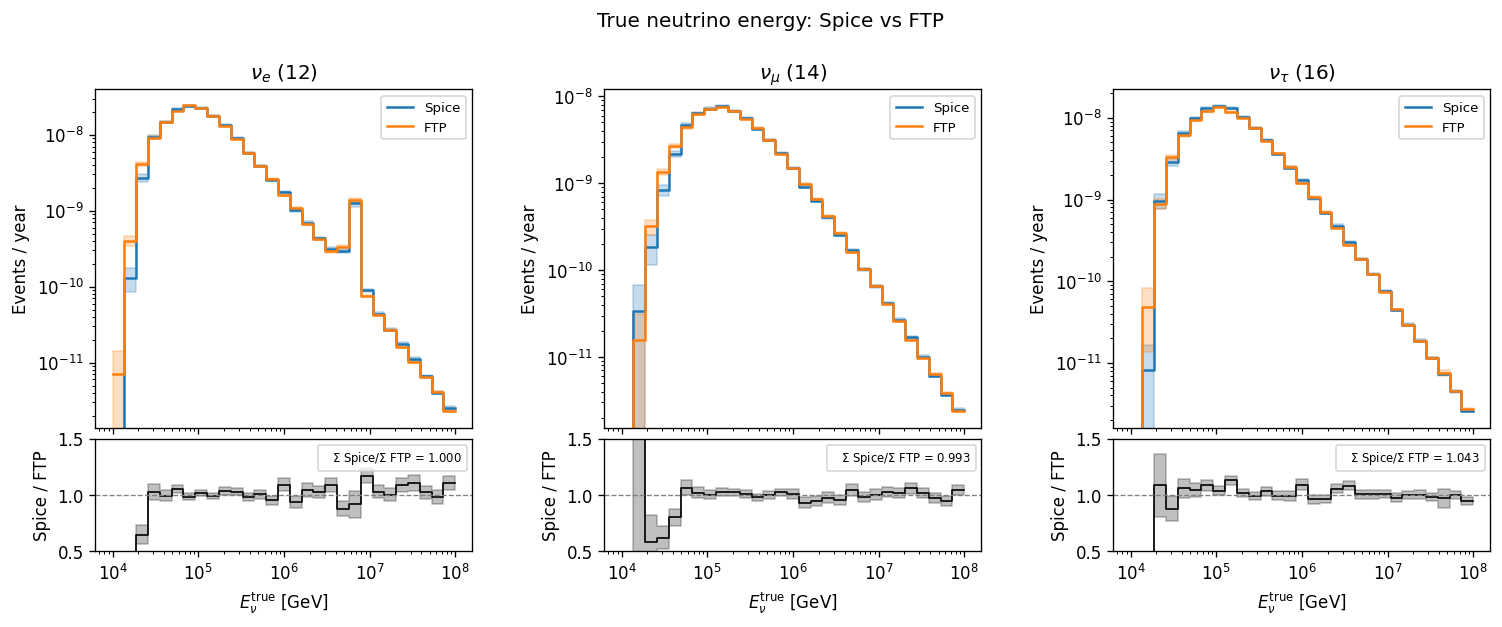

In [37]:
energy_bins = np.logspace(4, 8, 30)  # 10 TeV – 100 PeV

fig = compare_histograms(
    variable='MCPrimaryEnergy',
    bins=energy_bins,
    xlabel=r'$E_\nu^\mathrm{true}$ [GeV]',
    log_x=True,
    log_y=True,
    title='True neutrino energy: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'combined_MCPrimaryEnergy.png'), bbox_inches='tight', dpi=150)
plt.show()

### Reconstructed deposited energy

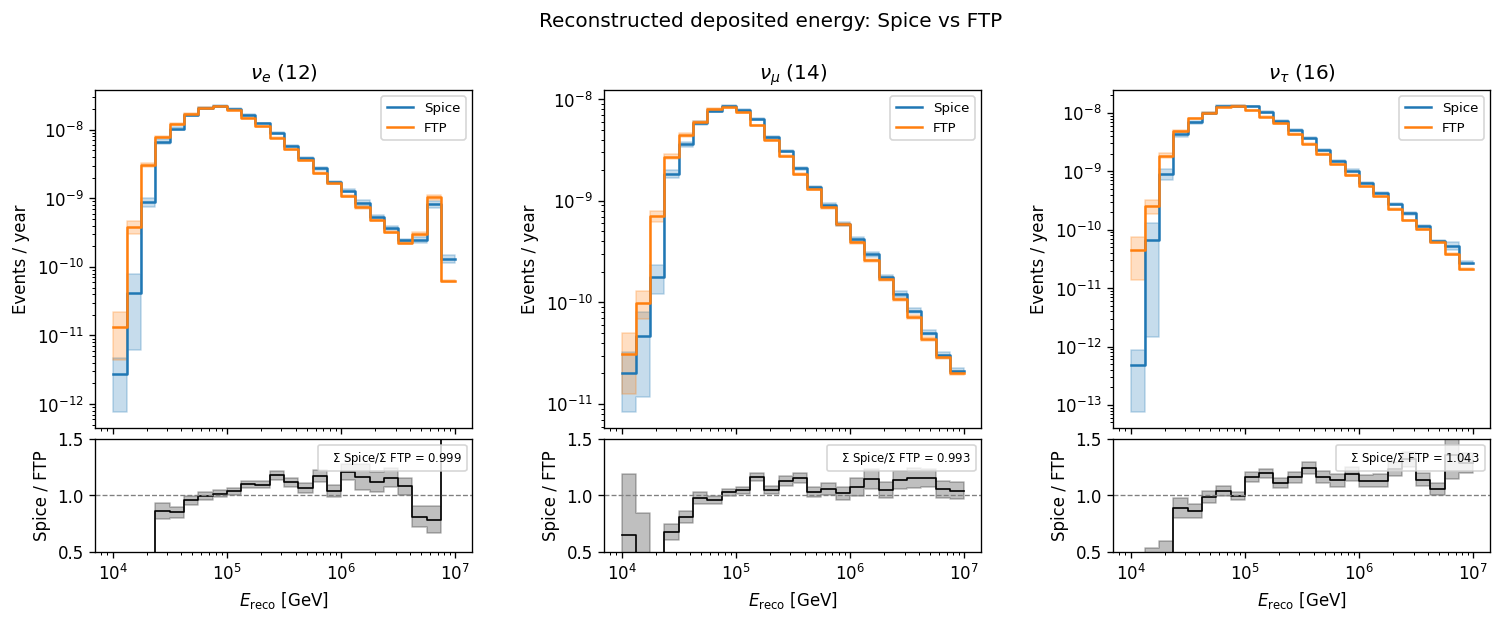

In [38]:
reco_energy_bins = np.logspace(4, 7, 25)  # 10 TeV – 10 PeV

fig = compare_histograms(
    variable='reco_energy',
    bins=reco_energy_bins,
    xlabel=r'$E_\mathrm{reco}$ [GeV]',
    log_x=True,
    log_y=True,
    title='Reconstructed deposited energy: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'combined_reco_energy.png'), bbox_inches='tight', dpi=150)
plt.show()

### True neutrino zenith

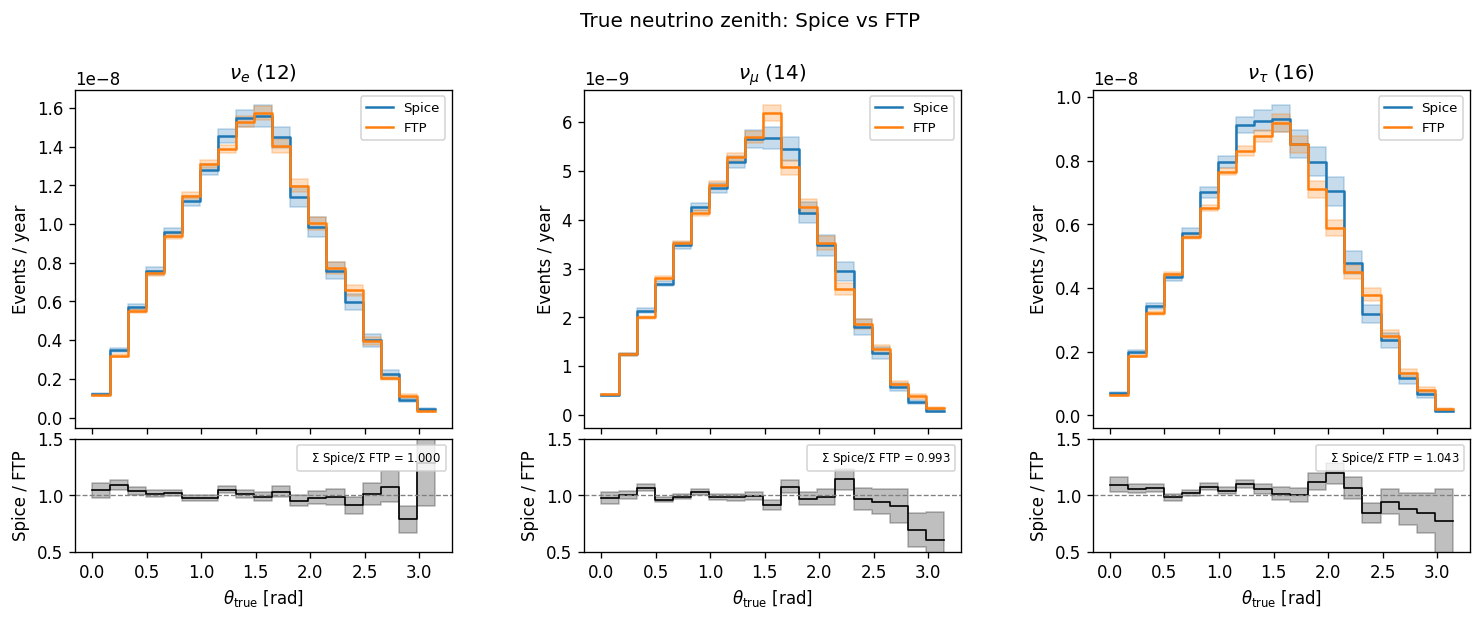

In [39]:
zenith_bins = np.linspace(0, np.pi, 20)

fig = compare_histograms(
    variable='MCPrimaryZenith',
    bins=zenith_bins,
    xlabel=r'$\theta_\mathrm{true}$ [rad]',
    title='True neutrino zenith: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'combined_MCPrimaryZenith.png'), bbox_inches='tight', dpi=150)
plt.show()

### Reconstructed direction

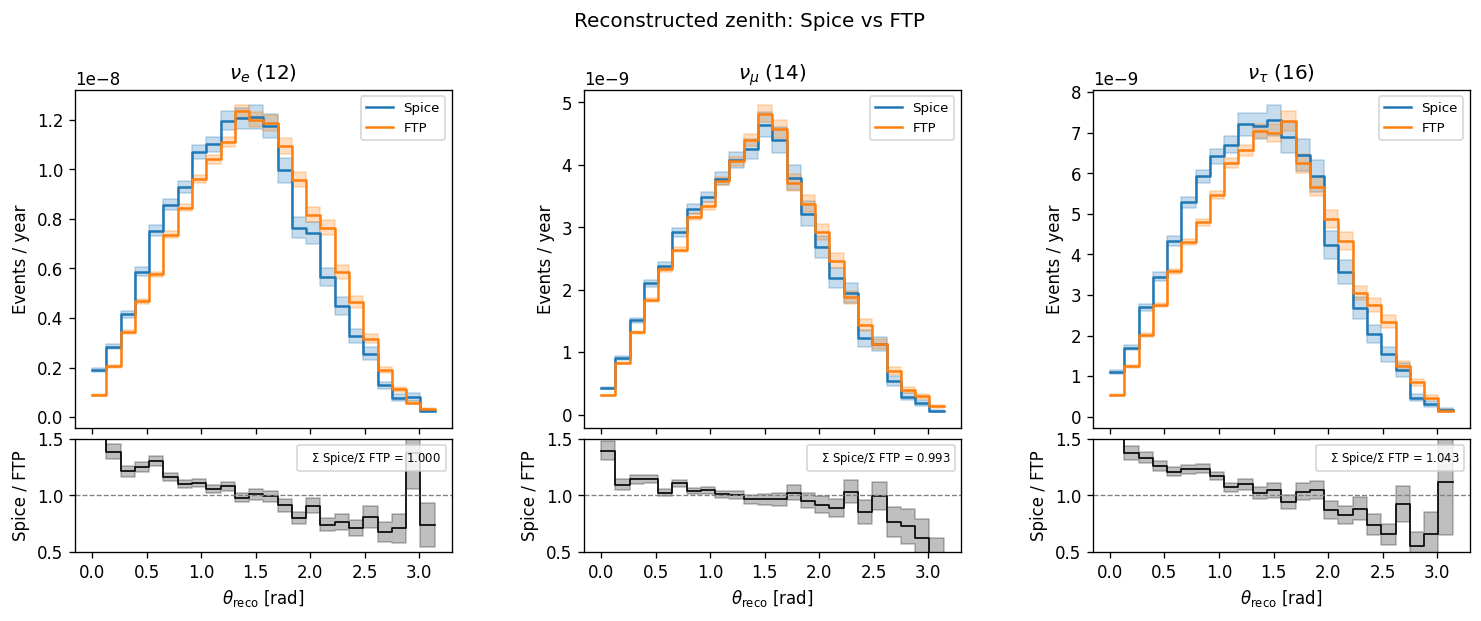

In [40]:
fig = compare_histograms(
    variable='reco_dir',
    bins=np.linspace(0, np.pi, 25),
    xlabel=r'$\theta_\mathrm{reco}$ [rad]',
    title='Reconstructed zenith: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'combined_reco_dir.png'), bbox_inches='tight', dpi=150)
plt.show()

## Split topology datasets (Track / Cascade / Double)

Compare Spice vs FTP within each reconstructed event topology.

In [41]:
BASE_FTP   = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split/'
    'IC86_pass2_SnowStorm_v2_FTP_Baseline_hdf-v7_noMuon_fluxlessweight_FinalTopology/'
)
BASE_SPICE = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split/'
    'IC86_pass2_SnowStorm_v2_Spice_Baseline_FinalTopology/'
)

TOPOLOGIES = ['track', 'cascade', 'double']

split_spice = {}
split_ftp   = {}

for topo in TOPOLOGIES:
    df_s = pd.read_parquet(
        BASE_SPICE + f'dataset_IC86_pass2_SnowStorm_v2_Spice_Baseline_{topo}.parquet'
    )
    df_f = pd.read_parquet(
        BASE_FTP + f'dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_hdf-v7_noMuon_fluxlessweight_{topo}.parquet'
    )
    df_s['astro_weight'] = get_astro_weight(df_s)
    df_f['astro_weight'] = get_astro_weight(df_f)
    split_spice[topo] = df_s
    split_ftp[topo]   = df_f
    print(f'{topo:8s}  Spice: {len(df_s):6,}  FTP: {len(df_f):6,}')

track     Spice: 40,820  FTP: 76,415
cascade   Spice: 115,562  FTP: 261,376
double    Spice: 14,743  FTP: 32,656


In [42]:
def compare_topology_histograms(
    topology,
    variable,
    bins,
    xlabel=None,
    log_x=False,
    log_y=False,
    title=None,
    figsize=(15, 5),
    ylim=None,
    ratio_ylim=None,
):
    """
    Compare Spice and FTP weighted histograms for a given topology and variable.

    Parameters
    ----------
    topology : str
        One of 'track', 'cascade', 'double'.
    variable : str
        Column name present in the split dataframes.
    bins : array-like
        Bin edges.
    xlabel : str, optional
        x-axis label; defaults to `variable`.
    log_x : bool
        Log scale on x-axis.
    log_y : bool
        Log scale on y-axis (main panel).
    title : str, optional
        Overall figure title.
    figsize : tuple
        Figure size.
    """
    bins   = np.asarray(bins)
    xlabel = xlabel or variable
    df_s   = split_spice[topology]
    df_f   = split_ftp[topology]

    fig = plt.figure(figsize=figsize)
    if title:
        fig.suptitle(title, y=1.01, fontsize=12)

    outer_gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    for col_idx, (flavor_label, pdg_abs) in enumerate(FLAVORS.items()):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer_gs[col_idx],
            height_ratios=[3, 1],
            hspace=0.05,
        )
        ax_main  = fig.add_subplot(inner_gs[0])
        ax_ratio = fig.add_subplot(inner_gs[1], sharex=ax_main)

        mask_s = df_s['MCPrimaryType'].abs() == pdg_abs
        mask_f = df_f['MCPrimaryType'].abs() == pdg_abs

        vals_s = df_s.loc[mask_s, variable].values
        w_s    = df_s.loc[mask_s, 'astro_weight'].values
        vals_f = df_f.loc[mask_f, variable].values
        w_f    = df_f.loc[mask_f, 'astro_weight'].values

        h_s,  _ = np.histogram(vals_s, bins=bins, weights=w_s)
        h_f,  _ = np.histogram(vals_f, bins=bins, weights=w_f)
        h2_s, _ = np.histogram(vals_s, bins=bins, weights=w_s**2)
        h2_f, _ = np.histogram(vals_f, bins=bins, weights=w_f**2)
        err_s = np.sqrt(h2_s)
        err_f = np.sqrt(h2_f)

        ax_main.step(bins, np.append(h_s, h_s[-1]), where='post',
                     color='tab:blue', label='Spice')
        ax_main.fill_between(
            bins,
            np.append(h_s - err_s, (h_s - err_s)[-1]),
            np.append(h_s + err_s, (h_s + err_s)[-1]),
            step='post', alpha=0.25, color='tab:blue',
        )
        ax_main.step(bins, np.append(h_f, h_f[-1]), where='post',
                     color='tab:orange', label='FTP')
        ax_main.fill_between(
            bins,
            np.append(h_f - err_f, (h_f - err_f)[-1]),
            np.append(h_f + err_f, (h_f + err_f)[-1]),
            step='post', alpha=0.25, color='tab:orange',
        )

        ax_main.set_title(flavor_label)
        ax_main.set_ylabel('Events / year')
        ax_main.legend(fontsize=8)
        if log_y:
            ax_main.set_yscale('log')
        if log_x:
            ax_main.set_xscale('log')
        if ylim is not None:
            ax_main.set_ylim(*ylim)
        plt.setp(ax_main.get_xticklabels(), visible=False)

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio     = np.where(h_f > 0, h_s / h_f, np.nan)
            ratio_err = np.where(
                h_f > 0,
                ratio * np.sqrt(
                    (err_s / np.where(h_s > 0, h_s, 1))**2
                    + (err_f / np.where(h_f > 0, h_f, 1))**2
                ),
                np.nan,
            )

        ax_ratio.step(bins, np.append(ratio, ratio[-1]),
                      where='post', color='black', lw=1)
        ax_ratio.fill_between(
            bins,
            np.append(ratio - ratio_err, (ratio - ratio_err)[-1]),
            np.append(ratio + ratio_err, (ratio + ratio_err)[-1]),
            step='post', alpha=0.25, color='black',
        )
        int_ratio = h_s.sum() / h_f.sum() if h_f.sum() > 0 else np.nan
        ax_ratio.axhline(1.0, color='gray', linestyle='--', lw=0.8)
        ax_ratio.plot([], [], color='none', label=f'$\\Sigma$ Spice/$\\Sigma$ FTP = {int_ratio:.3f}')
        ax_ratio.legend(fontsize=7, loc='upper right', handlelength=0)
        ax_ratio.set_ylabel('Spice / FTP')
        ax_ratio.set_xlabel(xlabel)
        ax_ratio.set_ylim(*(ratio_ylim if ratio_ylim is not None else (0.5, 1.5)))
        if log_x:
            ax_ratio.set_xscale('log')

    plt.tight_layout()
    return fig

### Tracks

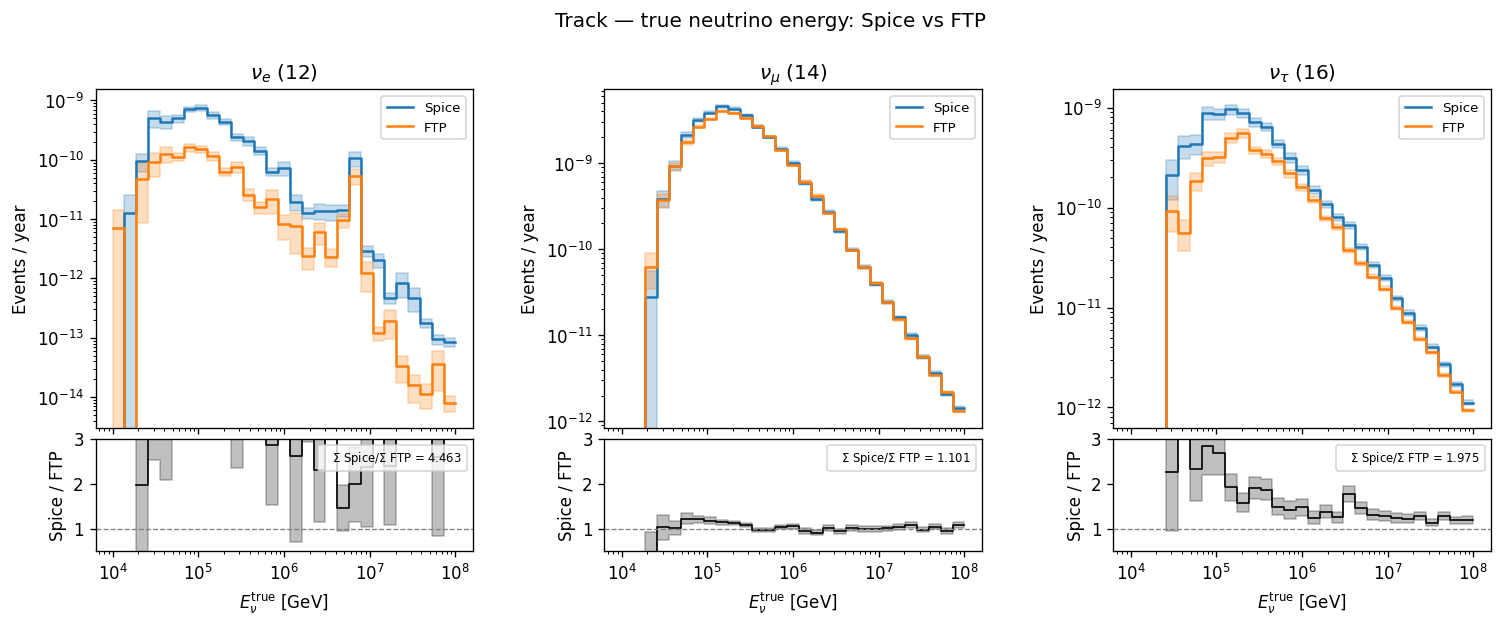

In [58]:
fig = compare_topology_histograms(
    topology='track',
    variable='MCPrimaryEnergy',
    bins=np.logspace(4, 8, 30),
    xlabel=r'$E_\nu^\mathrm{true}$ [GeV]',
    log_x=True,
    log_y=True,
    title='Track — true neutrino energy: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'track_MCPrimaryEnergy.png'), bbox_inches='tight', dpi=150)
plt.show()

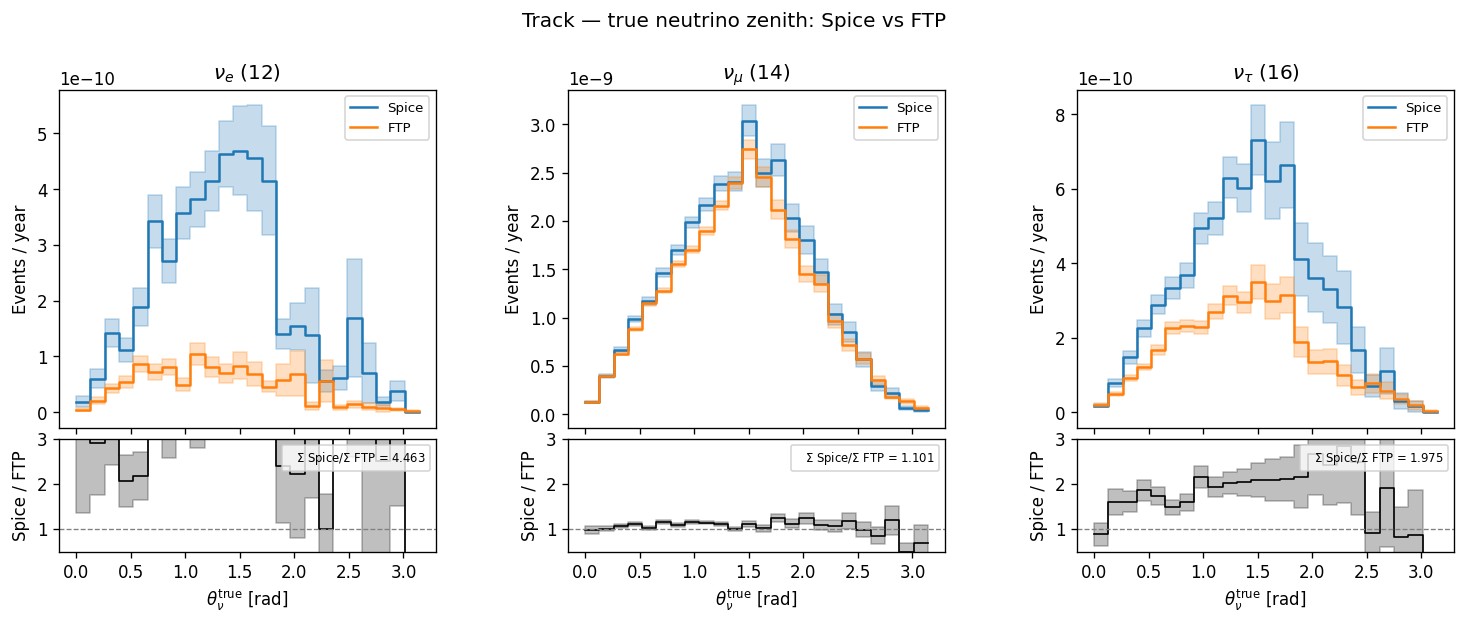

In [60]:
fig = compare_topology_histograms(
    topology='track',
    variable='MCPrimaryZenith',
    bins=np.linspace(0, np.pi, 25),
    xlabel=r'$\theta_\nu^\mathrm{true}$ [rad]',
    title='Track — true neutrino zenith: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'track_MCPrimaryZenith.png'), bbox_inches='tight', dpi=150)
plt.show()

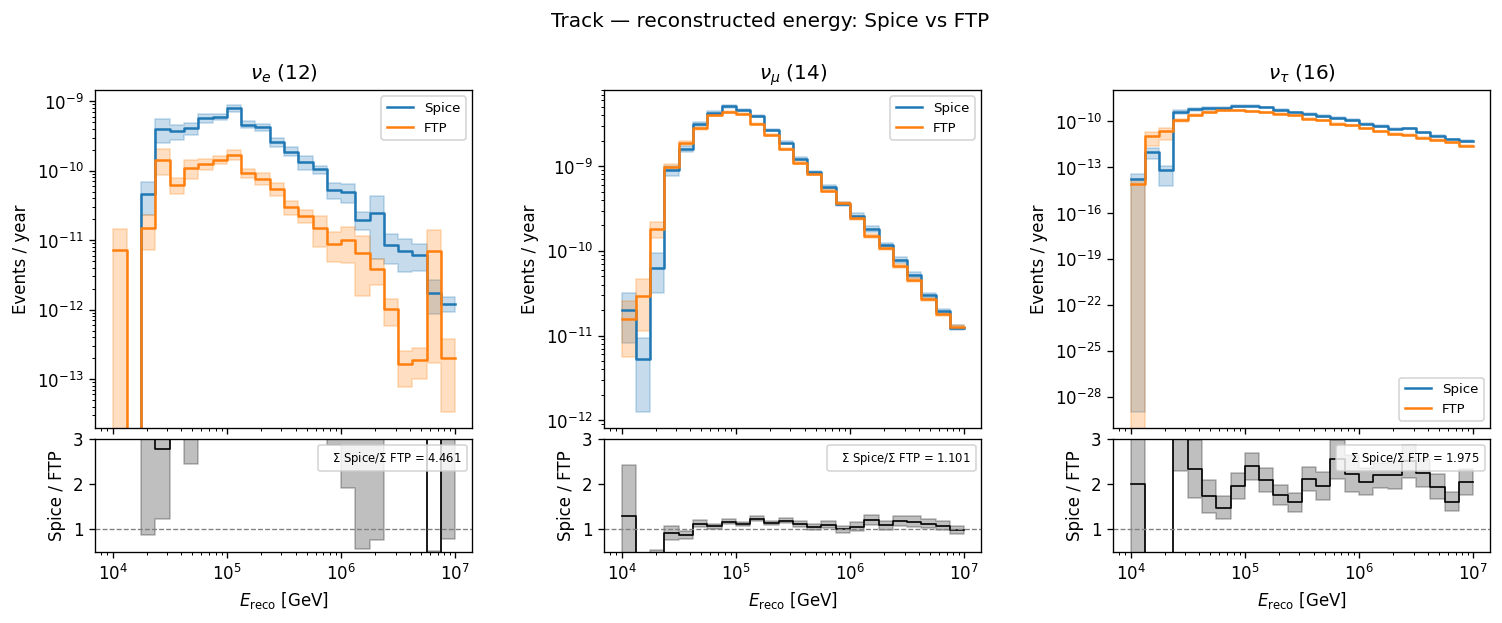

In [61]:
fig = compare_topology_histograms(
    topology='track',
    variable='reco_energy',
    bins=np.logspace(4, 7, 25),
    xlabel=r'$E_\mathrm{reco}$ [GeV]',
    log_x=True,
    log_y=True,
    title='Track — reconstructed energy: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'track_reco_energy.png'), bbox_inches='tight', dpi=150)
plt.show()

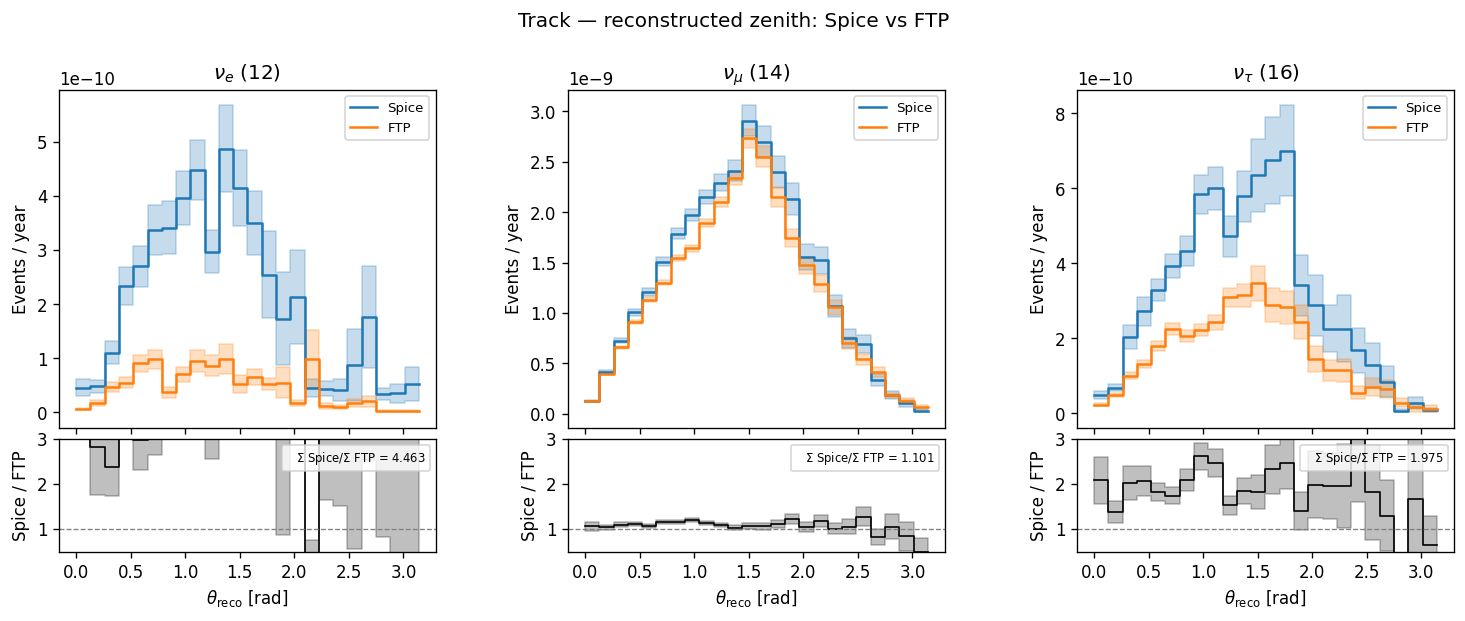

In [62]:
fig = compare_topology_histograms(
    topology='track',
    variable='reco_dir',
    bins=np.linspace(0, np.pi, 25),
    xlabel=r'$\theta_\mathrm{reco}$ [rad]',
    title='Track — reconstructed zenith: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'track_reco_dir.png'), bbox_inches='tight', dpi=150)
plt.show()

### Cascades

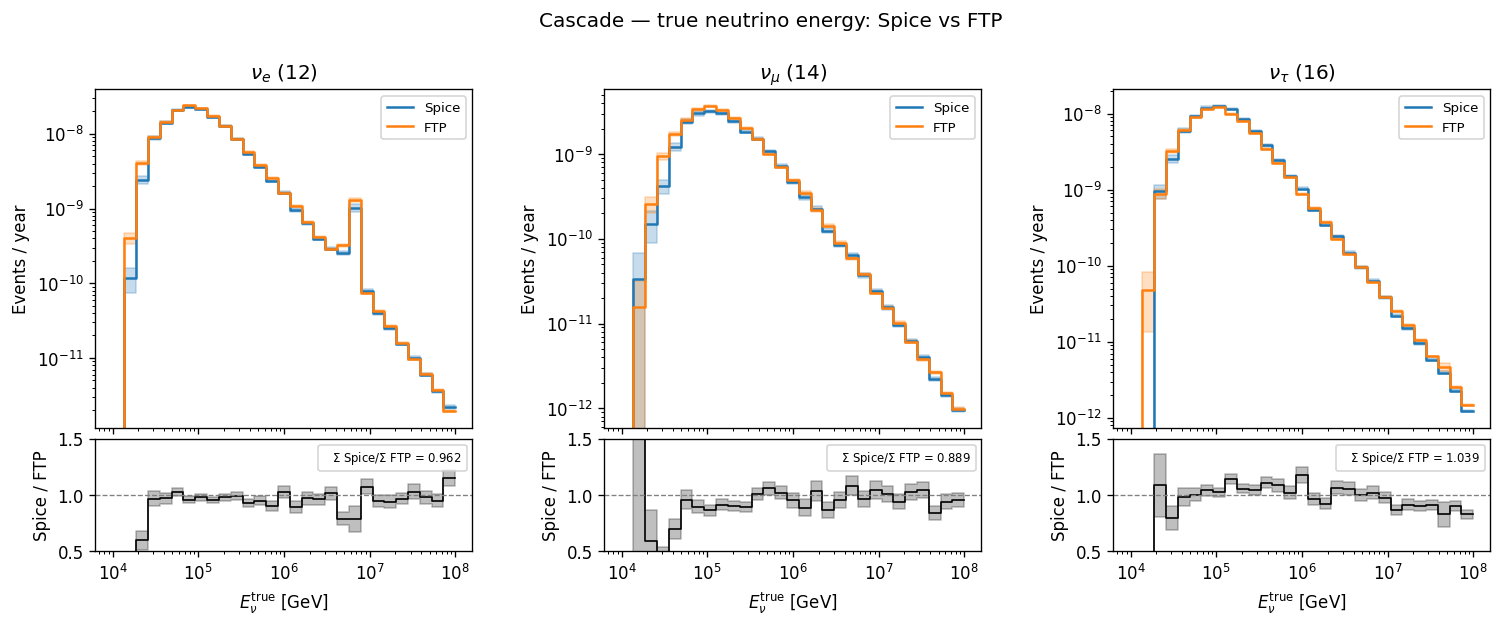

In [47]:
fig = compare_topology_histograms(
    topology='cascade',
    variable='MCPrimaryEnergy',
    bins=np.logspace(4, 8, 30),
    xlabel=r'$E_\nu^\mathrm{true}$ [GeV]',
    log_x=True,
    log_y=True,
    title='Cascade — true neutrino energy: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'cascade_MCPrimaryEnergy.png'), bbox_inches='tight', dpi=150)
plt.show()

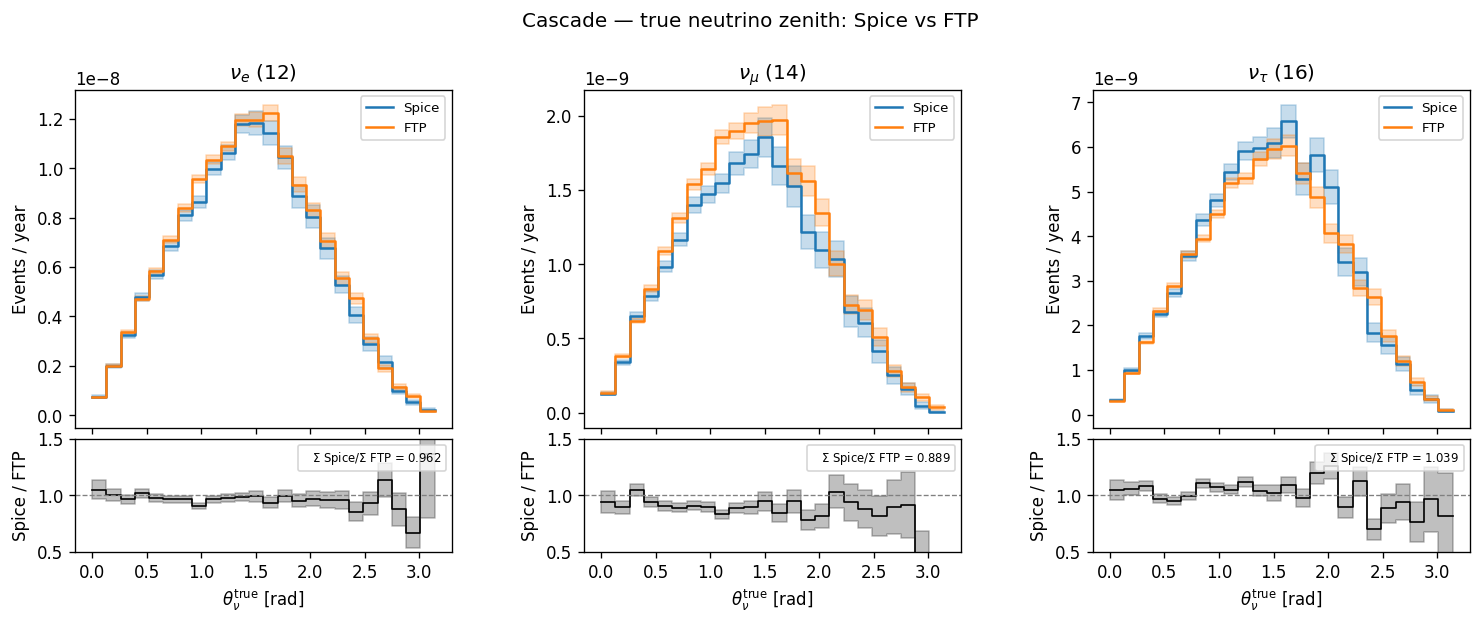

In [48]:
fig = compare_topology_histograms(
    topology='cascade',
    variable='MCPrimaryZenith',
    bins=np.linspace(0, np.pi, 25),
    xlabel=r'$\theta_\nu^\mathrm{true}$ [rad]',
    title='Cascade — true neutrino zenith: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'cascade_MCPrimaryZenith.png'), bbox_inches='tight', dpi=150)
plt.show()

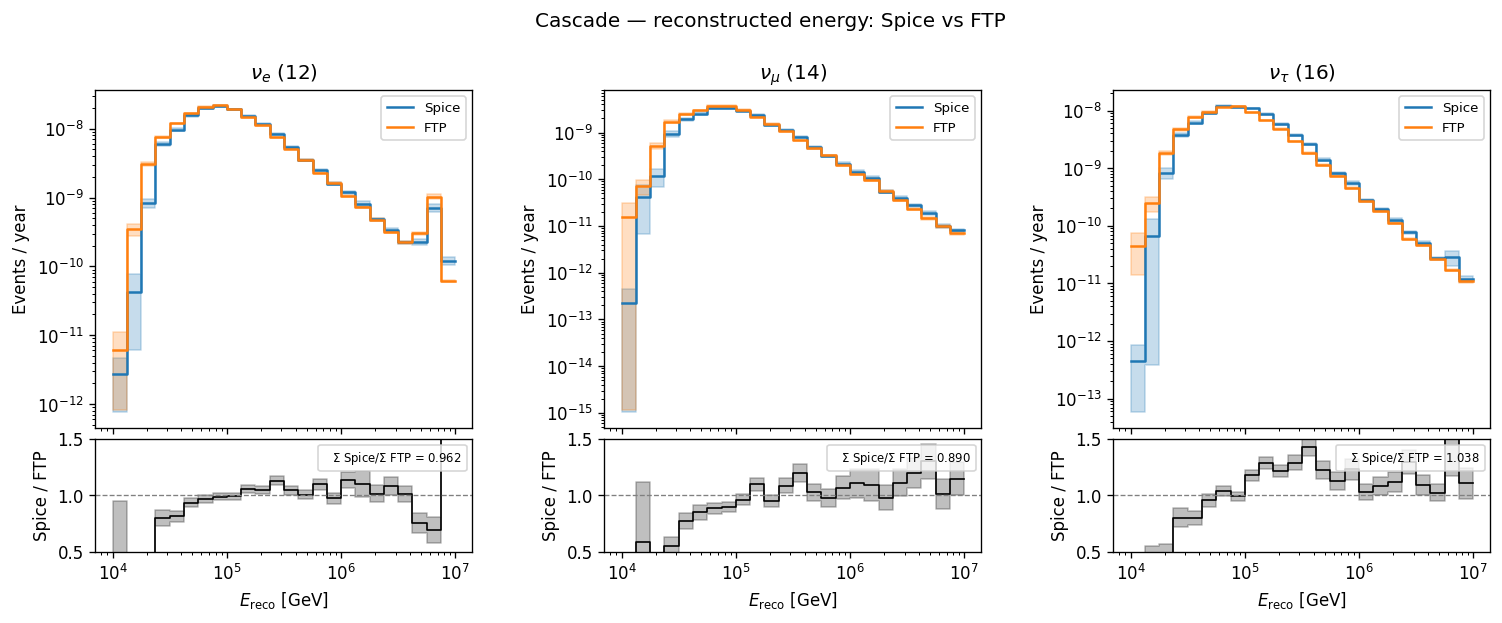

In [49]:
fig = compare_topology_histograms(
    topology='cascade',
    variable='reco_energy',
    bins=np.logspace(4, 7, 25),
    xlabel=r'$E_\mathrm{reco}$ [GeV]',
    log_x=True,
    log_y=True,
    title='Cascade — reconstructed energy: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'cascade_reco_energy.png'), bbox_inches='tight', dpi=150)
plt.show()

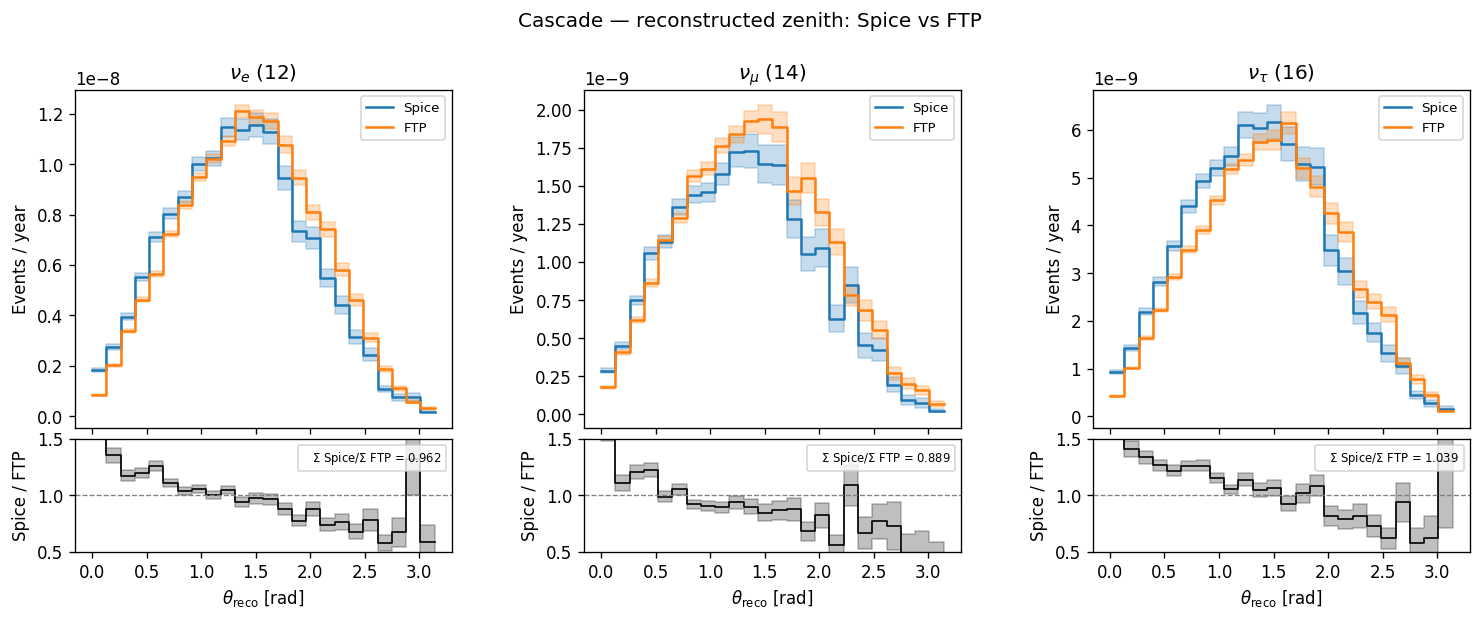

In [50]:
fig = compare_topology_histograms(
    topology='cascade',
    variable='reco_dir',
    bins=np.linspace(0, np.pi, 25),
    xlabel=r'$\theta_\mathrm{reco}$ [rad]',
    title='Cascade — reconstructed zenith: Spice vs FTP',
)
fig.savefig(os.path.join(save_path, 'cascade_reco_dir.png'), bbox_inches='tight', dpi=150)
plt.show()

### Double cascades

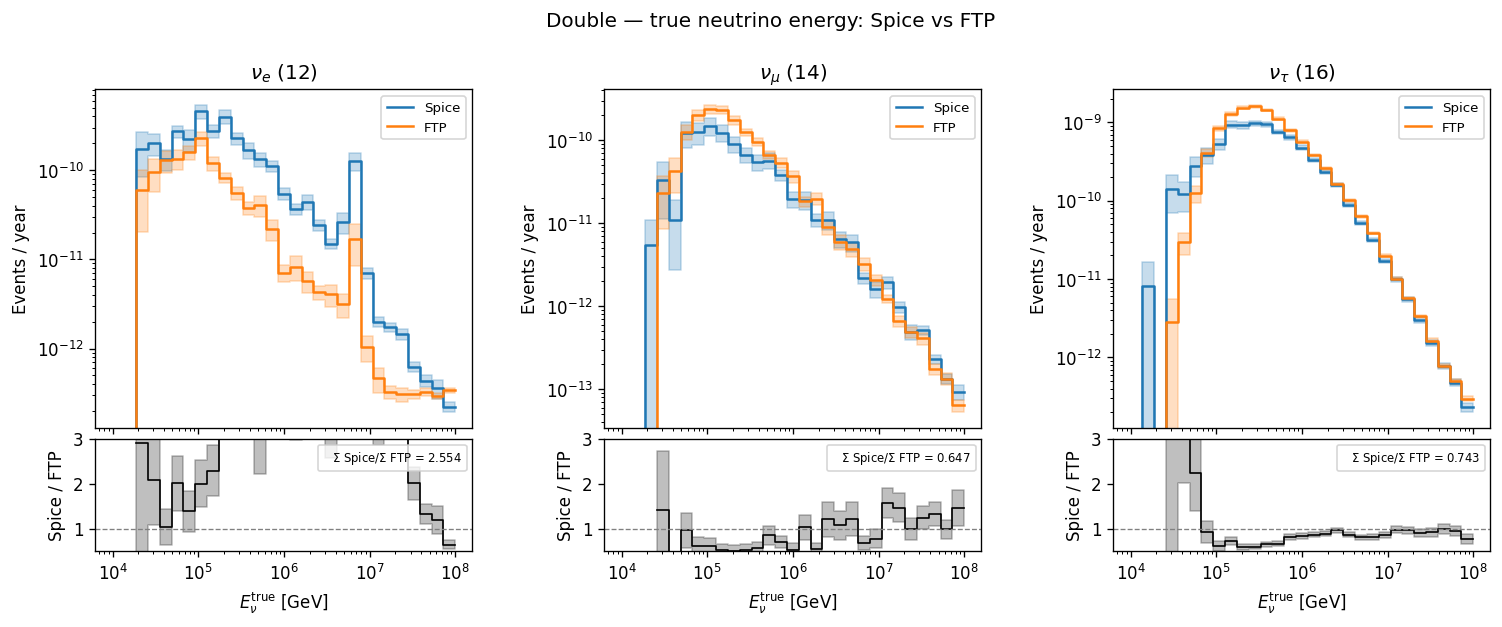

In [63]:
fig = compare_topology_histograms(
    topology='double',
    variable='MCPrimaryEnergy',
    bins=np.logspace(4, 8, 30),
    xlabel=r'$E_\nu^\mathrm{true}$ [GeV]',
    log_x=True,
    log_y=True,
    title='Double — true neutrino energy: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'double_MCPrimaryEnergy.png'), bbox_inches='tight', dpi=150)
plt.show()

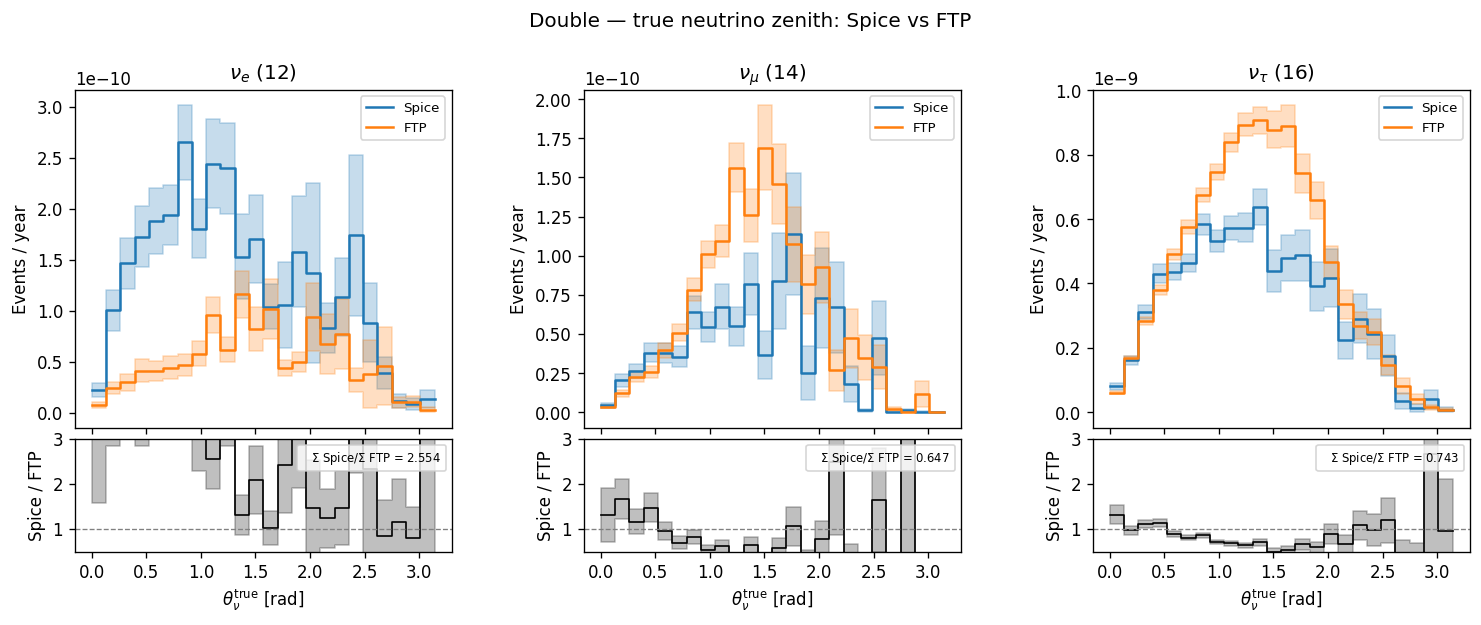

In [65]:
fig = compare_topology_histograms(
    topology='double',
    variable='MCPrimaryZenith',
    bins=np.linspace(0, np.pi, 25),
    xlabel=r'$\theta_\nu^\mathrm{true}$ [rad]',
    title='Double — true neutrino zenith: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'double_MCPrimaryZenith.png'), bbox_inches='tight', dpi=150)
plt.show()

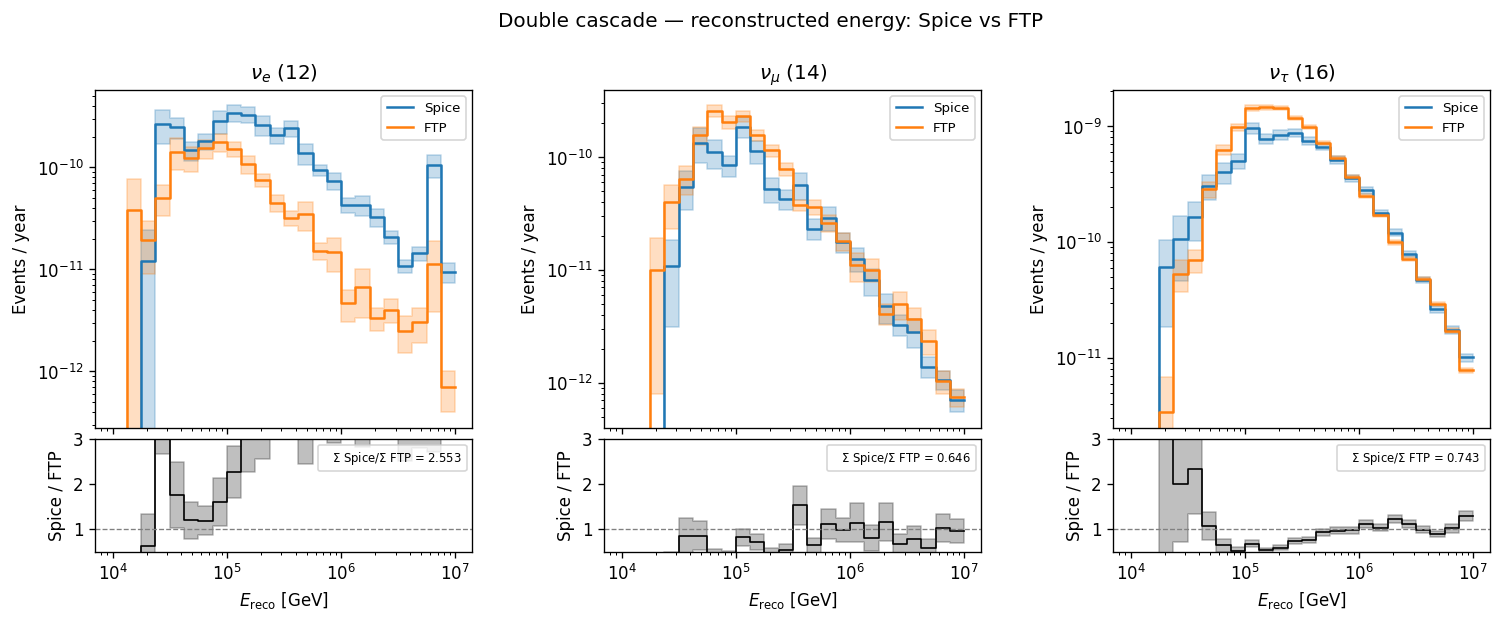

In [66]:
fig = compare_topology_histograms(
    topology='double',
    variable='reco_energy',
    bins=np.logspace(4, 7, 25),
    xlabel=r'$E_\mathrm{reco}$ [GeV]',
    log_x=True,
    log_y=True,
    title='Double cascade — reconstructed energy: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'double_reco_energy.png'), bbox_inches='tight', dpi=150)
plt.show()

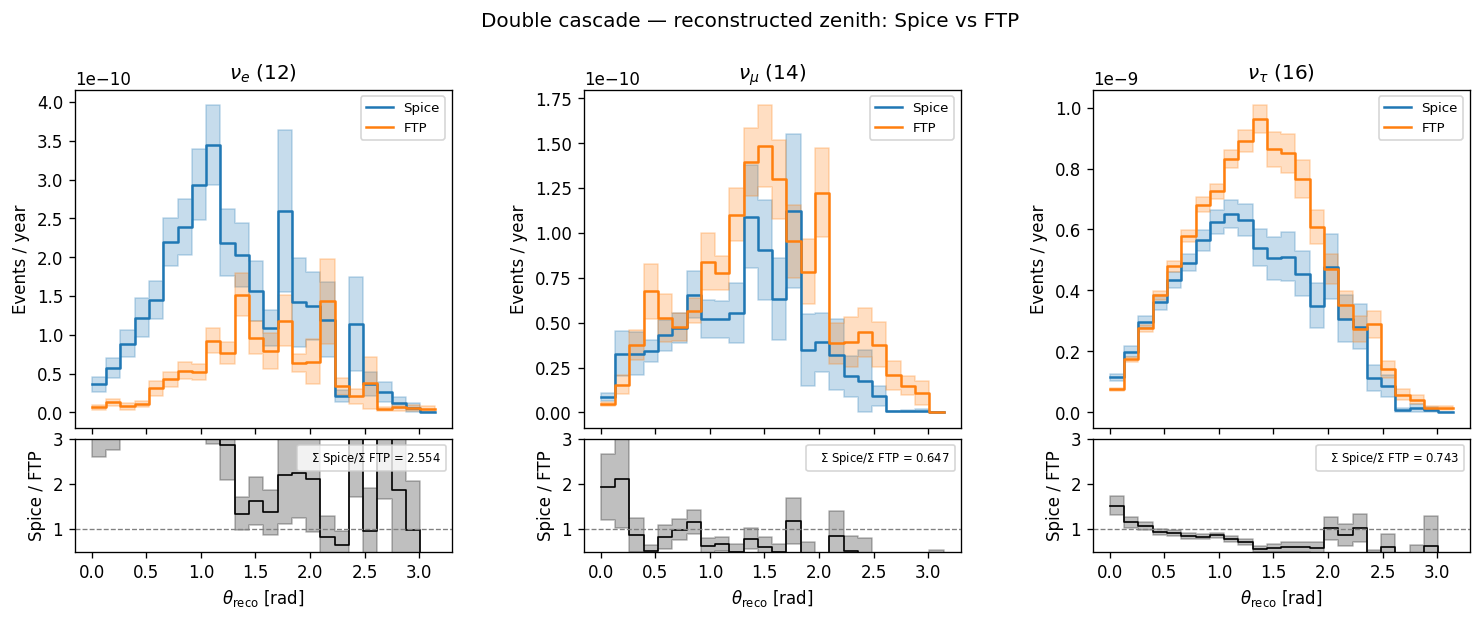

In [67]:
fig = compare_topology_histograms(
    topology='double',
    variable='reco_dir',
    bins=np.linspace(0, np.pi, 25),
    xlabel=r'$\theta_\mathrm{reco}$ [rad]',
    title='Double cascade — reconstructed zenith: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'double_reco_dir.png'), bbox_inches='tight', dpi=150)
plt.show()

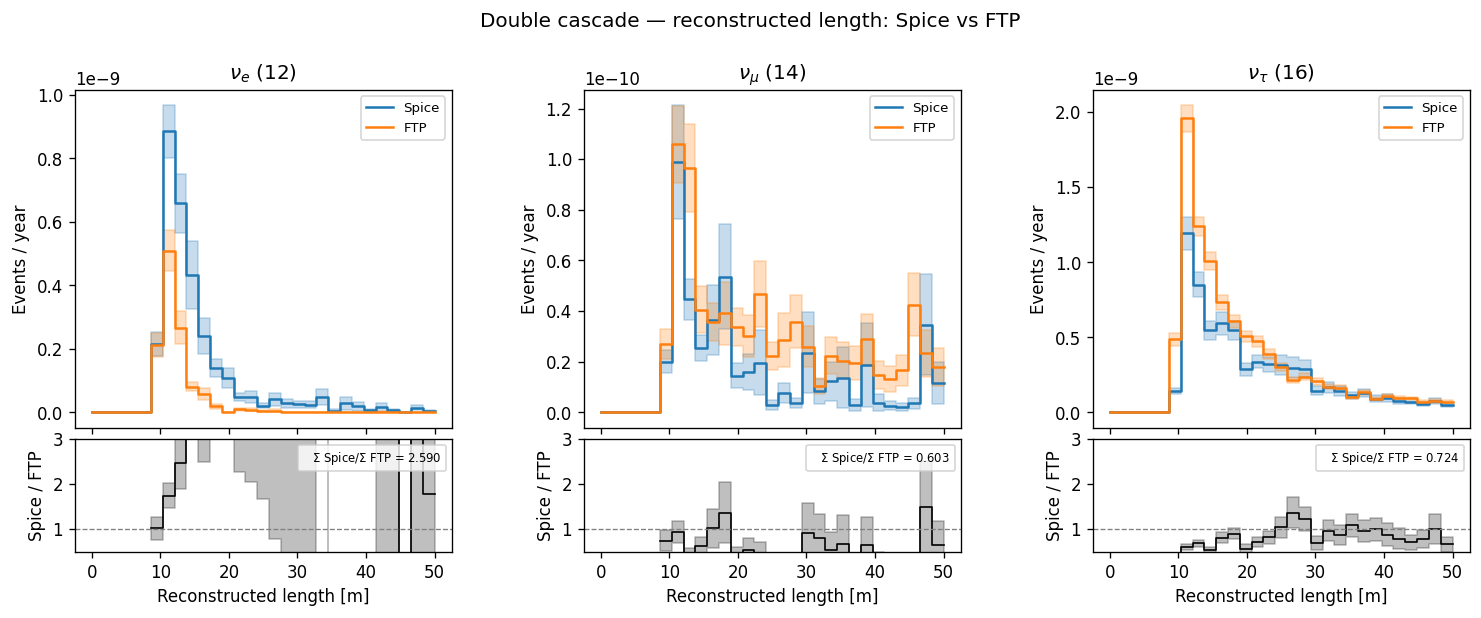

In [69]:
fig = compare_topology_histograms(
    topology='double',
    variable='reco_length',
    bins=np.linspace(0, 50, 30),
    xlabel='Reconstructed length [m]',
    title='Double cascade — reconstructed length: Spice vs FTP',
    ratio_ylim=(0.5, 3.0)
)
fig.savefig(os.path.join(save_path, 'double_reco_length.png'), bbox_inches='tight', dpi=150)
plt.show()